In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

fred_md = pd.read_csv("2025-11-MD.csv")
fred_qd = pd.read_csv("2025-11-QD.csv")

import gpflow
fred_md

2026-09-23 09:50:34.593571: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-23 09:50:34.666622: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-23 09:50:34.795778: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-23 09:50:34.797388: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-23 09:50:36.129795: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

,sasdate,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
0,Transform:,5.000,5.0,5.000,5.000000e+00,5.00000,5.0000,5.0000,5.0000,5.0000,...,6.000,6.000,6.00,6.00,6.00,2.0,6.00,6.00,6.0000,1.0000
1,1/1/1959,2583.560,2426.0,15.188,2.766768e+05,17689.23968,21.9998,23.6312,22.5507,32.1377,...,18.294,10.152,2.13,2.45,2.04,NaN,6476.00,12298.00,84.2043,NaN
2,2/1/1959,2593.596,2434.8,15.346,2.787140e+05,17819.01912,22.4306,23.9501,22.7461,32.3734,...,18.302,10.167,2.14,2.46,2.05,NaN,6476.00,12298.00,83.5280,NaN
3,3/1/1959,2610.396,2452.7,15.491,2.777753e+05,17967.91336,22.7538,24.0951,22.8577,32.3734,...,18.289,10.185,2.15,2.45,2.07,NaN,6508.00,12349.00,81.6405,NaN
4,4/1/1959,2627.446,2470.0,15.435,2.833627e+05,17978.97983,23.2384,24.4431,23.1926,32.8841,...,18.300,10.221,2.16,2.47,2.08,NaN,6620.00,12484.00,81.8099,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
798,6/1/2025,20575.971,16664.7,123.894,1.556845e+06,723033.00000,101.5650,97.7300,97.6957,98.3013,...,120.208,132.386,32.40,37.23,28.94,60.7,549233.53,935818.74,5555.2012,18.3246
799,7/1/2025,20625.729,16718.9,124.370,1.565742e+06,727727.00000,101.3472,97.6320,97.7761,98.2797,...,120.036,132.778,32.54,37.28,29.13,61.7,547313.91,935386.44,5585.9753,16.4718
800,8/1/2025,20646.475,16726.7,124.805,NaN,732059.00000,101.2704,97.4790,97.6309,98.2182,...,120.329,133.209,32.60,37.50,29.10,58.2,547222.69,937067.87,5624.5492,15.7545
801,9/1/2025,NaN,NaN,NaN,NaN,733258.00000,NaN,NaN,NaN,NaN,...,NaN,NaN,32.74,37.64,29.23,55.1,545946.56,938188.14,5644.1810,15.6325


In [2]:
def trans_2(x):
    dt = np.diff(x, append=np.nan)
    return dt 

def trans_4(x):
    return np.log(x)

def trans_5(x):
    dt = np.diff(np.log(x), append=np.nan)
    return dt

def trans_6(x):
    ddt = np.diff(np.diff(np.log(x)), append=np.nan)
    return ddt

def transform(x, ind):
    if ind == 1:
        return x
    elif ind == 2:
        return trans_2(x)
    elif ind == 4:
        return trans_4(x)
    elif ind == 5:
        return trans_5(x)
    elif ind == 6:
        return trans_6(x)

[[1.95916153e+03 1.00000000e+00]
 [1.95941342e+03 1.00000000e+00]
 [1.95966530e+03 1.00000000e+00]
 [1.95991444e+03 1.00000000e+00]
 [1.96016427e+03 1.00000000e+00]
 [1.96041615e+03 1.00000000e+00]
 [1.96066804e+03 1.00000000e+00]
 [1.96091718e+03 1.00000000e+00]
 [1.96116153e+03 1.00000000e+00]
 [1.96141342e+03 1.00000000e+00]
 [1.96166530e+03 1.00000000e+00]
 [1.96191444e+03 1.00000000e+00]
 [1.96216153e+03 1.00000000e+00]
 [1.96241342e+03 1.00000000e+00]
 [1.96266530e+03 1.00000000e+00]
 [1.96291444e+03 1.00000000e+00]
 [1.96316153e+03 1.00000000e+00]
 [1.96341342e+03 1.00000000e+00]
 [1.96366530e+03 1.00000000e+00]
 [1.96391444e+03 1.00000000e+00]
 [1.96416427e+03 1.00000000e+00]
 [1.96441615e+03 1.00000000e+00]
 [1.96466804e+03 1.00000000e+00]
 [1.96491718e+03 1.00000000e+00]
 [1.96516153e+03 1.00000000e+00]
 [1.96541342e+03 1.00000000e+00]
 [1.96566530e+03 1.00000000e+00]
 [1.96591444e+03 1.00000000e+00]
 [1.96616153e+03 1.00000000e+00]
 [1.96641342e+03 1.00000000e+00]
 [1.966665

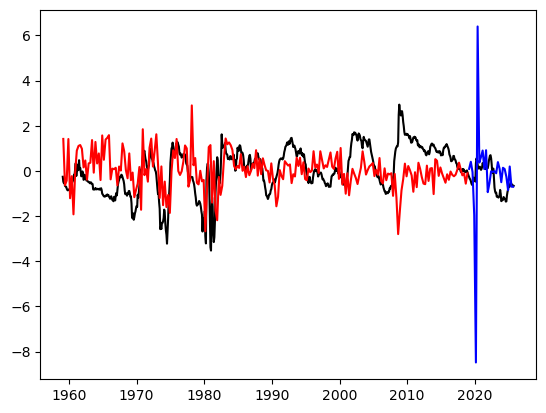

In [3]:
predictor_names = ["BAAFFM"] #, "HOUST", "S&P 500", "FEDFUNDS", "GS10", "BAAFFM", "CPIAUCSL"]
transforms = [1]  # These transforms are different from the ones in the DF, problem?

fred_preds = fred_md[predictor_names][2:]
index = pd.to_datetime(fred_md["sasdate"][2:])
index = (index.dt.year + (index.dt.dayofyear - 1) / 365.25).to_numpy()
source_X = []
source_y = []
lengths = []


for i, (t, f) in enumerate(zip(transforms, fred_preds)):
    # if f not in predictor_names_reduced:
    #     continue
    fp = fred_preds[f].ffill()
    
    transformed = transform(fp.to_numpy(), t)

    transformed = (transformed - np.nanmean(transformed)) / np.nanstd(transformed)
   
    #transformed = np.nan_to_num(transformed, nan=np.min(transformed))
    source_X.append(np.hstack((index[:,None], i*np.ones_like(index[:,None]))))
    source_y.append(np.hstack((transformed.reshape(-1, 1), i*np.ones_like(transformed.reshape(-1, 1)))))
    
    lengths.append(len(fp))

target = fred_qd["GDPC1"]
index = pd.to_datetime(fred_qd["sasdate"][2:])
target_X = (index.dt.year + (index.dt.dayofyear - 1) / 365.25).to_numpy()
target_X_train, target_X_test = target_X[:int(0.9*len(target_X))], target_X[int(0.9*len(target_X)):]
target_X_train = np.hstack((target_X_train[:,None], (i+1)*np.ones_like(target_X_train[:,None])))
target_X_test = np.hstack((target_X_test[:,None], (i+1)*np.ones_like(target_X_test[:,None])))
print(target_X_train)
target = target.ffill()
target = transform(target[2:], 5)
target = np.nan_to_num(target, -1)
target = (target - np.mean(target)) / np.std(target)
target_train, target_test =  target[:int(0.9*len(target))], target[int(0.9*len(target)):]

target_y_train = np.hstack((target_train[:,None], (i+1)*np.ones_like(target_train[:,None])))
target_y_test = np.hstack((target_test[:,None], (i+1)*np.ones_like(target_test[:,None])))
for i in range(len(source_X)):
    plt.plot(source_X[i][:,0], source_y[i][:,0], color="black")
plt.plot(target_X_train[:,0], target_y_train[:,0], color="red")
plt.plot(target_X_test[:,0], target_y_test[:,0], color="blue")
plt.show()

data_X = source_X + [target_X_train]
data_y = source_y + [target_y_train]

X = np.vstack(tuple(data_X))
y = np.vstack(tuple(data_y))

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value   │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ SparseCMOGP.kernel.kernels[1].W               

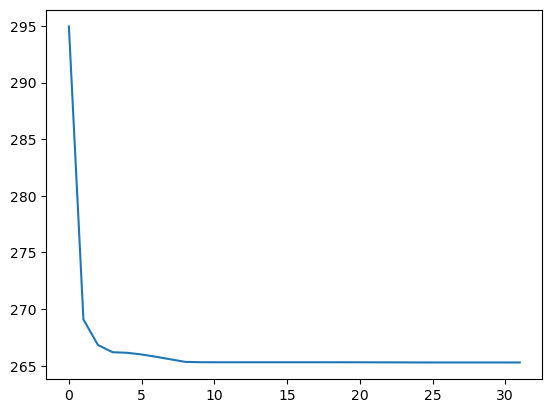

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═══════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                 │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═══════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.7962718434514797    │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼───────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.722935495043312     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────

In [6]:
import os
import sys
import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)
from pathlib import Path
home = Path.home()
at_dir = home / "src" / "at-gpflow"
sys.path.append(str(at_dir))
from atmodel import SparseCMOGP, ConditionalMOGP
from atlikelihood import TransferLikelihood
import gpflow as gpf
from robust_svgp import LMCInducingVariable, LMCInducingPointsBase

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

output_dim = len(data_X) # Number of outputs
rank = 1 # Rank of W

# Base kernel
k = gpf.kernels.Matern12(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
nIVS = 100 * output_dim
ivs = np.linspace(np.min(X[:,0]), np.max(X[:,0]), nIVS).reshape(-1, 1)
iv_ind = [j * np.ones((int(nIVS/output_dim), 1)) for j in range(output_dim)]
iv_ind = np.concatenate(iv_ind) 
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))

kern = k * coreg
#m = ConditionalMOGP((X, y), kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
model2 = SparseCMOGP((X, y), conditioning_index=(i+1), exact_target=False, kernel=kern, jitter=1e-2, inducing_variable=LMCInducingPointsBase(ivs), likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#gpf.set_trainable(m.kernel.kernels[0].variance, True
#gpf.set_trainable(m.likelihood.source.variance, False)
#print(model2.conditional_likelihood(decompose_likelihood=True))

gpf.utilities.print_summary(model2)
optimize(model2)
gpf.utilities.print_summary(model2)

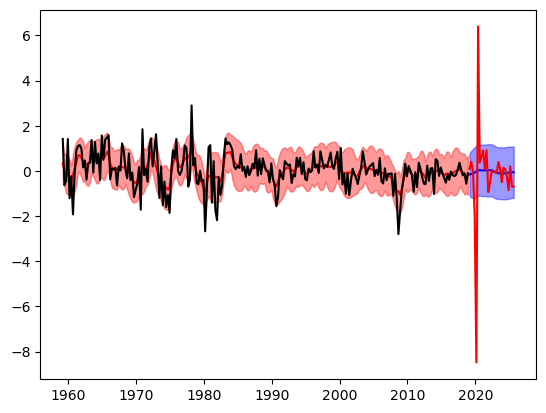

In [7]:
fmean, fvar = model2.predict_f(target_X_train)
fmean_tst, fvar_tst = model2.predict_f(target_X_test)
plt.plot(target_X_train[:,0], fmean, color="red")
plt.fill_between(
    target_X_train[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="red",
    alpha=0.4,
)
plt.plot(target_X_test[:,0], fmean_tst, color="blue")
plt.fill_between(
    target_X_test[:, 0],
    (fmean_tst - 2 * np.sqrt(fvar_tst))[:, 0],
    (fmean_tst + 2 * np.sqrt(fvar_tst))[:, 0],
    color="blue",
    alpha=0.4,
)
plt.plot(target_X_train[:,0], target_y_train[:,0], color="black")
plt.plot(target_X_test[:,0], target_y_test[:,0], color="red")